In [1]:
!pip install onnx
!pip install onnxscript
!pip install onnx2torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.6 MB/s eta 0:00:00


In [2]:
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import numpy as np
import pandas as pd

import scipy.stats as stats

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from onnx2torch import convert
from onnx2torch.utils.common import OperationConverterResult, onnx_mapping_from_node
from onnx2torch.node_converters.registry import add_converter

from google.colab import files

import copy

In [3]:
def compute_l1_norm(model):
  l1 = 0
  for name, param in model.named_parameters():
    # Check if the parameter name contains 'weight' and does NOT contain 'bias'
    # The 'weight' check is often redundant if you skip 'bias', but good practice.
    # The key is to check for 'bias' in the name and skip it.
    if 'bias' not in name:
      l1 += torch.sum(torch.abs(param))

  return l1

In [5]:
files.upload()

Saving lindex_deep.onnx to lindex_deep.onnx
Saving lindex.onnx to lindex.onnx


{'lindex_deep.onnx': b'\x08\x07\x12\x07pytorch\x1a\x041.10:\xca\xa4\x10\nd\n\nmodelInput\n\nfc1.weight\n\x08fc1.bias\x12\x0213\x1a\x06Gemm_0"\x04Gemm*\x0f\n\x05alpha\x15\x00\x00\x80?\xa0\x01\x01*\x0e\n\x04beta\x15\x00\x00\x80?\xa0\x01\x01*\r\n\x06transB\x18\x01\xa0\x01\x02\n\x16\n\x0213\x12\x0214\x1a\x06Relu_1"\x04Relu\n\\\n\x0214\n\nfc2.weight\n\x08fc2.bias\x12\x0215\x1a\x06Gemm_2"\x04Gemm*\x0f\n\x05alpha\x15\x00\x00\x80?\xa0\x01\x01*\x0e\n\x04beta\x15\x00\x00\x80?\xa0\x01\x01*\r\n\x06transB\x18\x01\xa0\x01\x02\n\x16\n\x0215\x12\x0216\x1a\x06Relu_3"\x04Relu\n\\\n\x0216\n\nfc3.weight\n\x08fc3.bias\x12\x0217\x1a\x06Gemm_4"\x04Gemm*\x0f\n\x05alpha\x15\x00\x00\x80?\xa0\x01\x01*\x0e\n\x04beta\x15\x00\x00\x80?\xa0\x01\x01*\r\n\x06transB\x18\x01\xa0\x01\x02\n\x16\n\x0217\x12\x0218\x1a\x06Relu_5"\x04Relu\n^\n\x0218\n\x0bfc3a.weight\n\tfc3a.bias\x12\x0219\x1a\x06Gemm_6"\x04Gemm*\x0f\n\x05alpha\x15\x00\x00\x80?\xa0\x01\x01*\x0e\n\x04beta\x15\x00\x00\x80?\xa0\x01\x01*\r\n\x06transB\x18\x01\xa0\x

# Datasets

## Generated from VNNComp Specifications

In [6]:
df_spec = pd.read_csv('nn4sys_spec_all.txt', header=None, names=['xlb', 'xub', 'ylb', 'yub'])
df_spec['x_center'] = (df_spec['xlb'] + df_spec['xub']) / 2
df_spec['y_center'] = (df_spec['ylb'] + df_spec['yub']) / 2
df_spec['x_width'] = df_spec['xub'] - df_spec['xlb']
df_spec['y_width'] = df_spec['yub'] - df_spec['ylb']
df_spec.head()

,xlb,xub,ylb,yub,x_center,y_center,x_width,y_width
0,1.050449e-07,4.989634e-07,-0.001366,0.001393,3.020042e-07,0.000014,3.939185e-07,0.002759
1,4.464409e-07,5.252246e-07,-0.001359,0.001400,4.858328e-07,0.000021,7.878370e-08,0.002759
2,4.989634e-07,5.514858e-07,-0.001352,0.001407,5.252246e-07,0.000028,5.252241e-08,0.002759
3,5.252246e-07,5.777471e-07,-0.001345,0.001414,5.514858e-07,0.000034,5.252247e-08,0.002759
4,5.514858e-07,6.040083e-07,-0.001338,0.001421,5.777470e-07,0.000041,5.252247e-08,0.002759


In [7]:
df_spec.describe()

,xlb,xub,ylb,yub,x_center,y_center,x_width,y_width
count,1.449970e+05,1.449970e+05,144997.000000,144997.000000,1.449970e+05,144997.000000,1.449970e+05,1.449970e+05
mean,2.100630e-02,2.102010e-02,0.498624,0.501383,2.101320e-02,0.500003,1.379169e-05,2.758640e-03
std,6.109434e-02,6.120236e-02,0.288672,0.288672,6.114832e-02,0.288672,1.623513e-04,9.416291e-15
min,1.050449e-07,4.989634e-07,-0.001366,0.001393,3.020042e-07,0.000014,5.215406e-08,2.758640e-03
25%,1.358730e-03,1.358861e-03,0.248629,0.251388,1.358795e-03,0.250009,7.881317e-08,2.758640e-03
50%,4.453904e-03,4.454062e-03,0.498624,0.501383,4.453983e-03,0.500003,2.360903e-07,2.758640e-03
75%,1.477055e-02,1.477210e-02,0.748619,0.751378,1.477133e-02,0.749998,9.979121e-07,2.758640e-03
max,9.977580e-01,1.000000e+00,0.998614,1.001372,9.988790e-01,0.999993,1.186711e-02,2.758640e-03


In [8]:
X_spec = torch.tensor(df_spec['x_center'].values, dtype=torch.float32).reshape(-1, 1)
y_spec = torch.tensor(df_spec['y_center'].values, dtype=torch.float32).reshape(-1, 1)
ds_spec = torch.utils.data.TensorDataset(X_spec, y_spec)
spec_loader = torch.utils.data.DataLoader(ds_spec, batch_size=32)

The dataset really looks like the x-values (keys) follow a lognormal distribution.

array([[<Axes: title={'center': 'x_center'}>,
        <Axes: title={'center': 'log_x_center'}>],
       [<Axes: title={'center': 'y_center'}>,
        <Axes: title={'center': 'log_y_center'}>]], dtype=object)

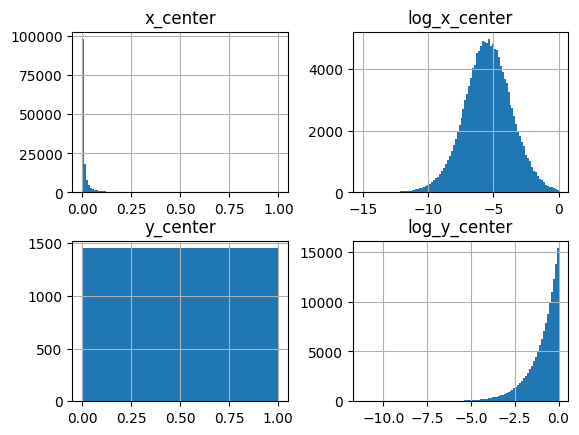

In [9]:
df_spec['log_x_center'] = np.log(df_spec['x_center'])
df_spec['log_y_center'] = np.log(df_spec['y_center'])
df_spec.hist(column=['x_center', 'log_x_center', 'y_center', 'log_y_center'], bins=100)

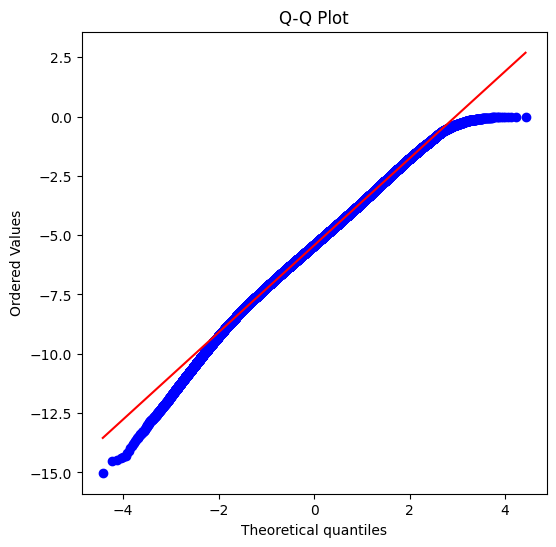

In [10]:
plt.figure(figsize=(6, 6))
stats.probplot(df_spec['log_x_center'].values, dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

In [11]:
shape, loc, scale = stats.lognorm.fit(df_spec['x_center'].values)
print(f'Shape: {shape}, Location: {loc}, Scale: {scale}')

d_stat, p_value = stats.kstest(df_spec['x_center'].values, 'lognorm', args=(shape, loc, scale))
print(f'D-statistic: {d_stat}, p-value: {p_value}')

Shape: 1.8058882153256437, Location: -1.095450399574499e-05, Scale: 0.004456622002954636
D-statistic: 0.006984443306672472, p-value: 1.4293965761851272e-06


The p-value of the KS-Test is very small and thus our data is *not* lognormal distributed!

You can also see it in the quantile-quantile plot: Towards the very left and right of the plot, the samples deviate.

## Generated from Ouroboros Paper

See Wei et al.: *Building Verified Neural Networks for Computer Systems with Ouroboros* and their artifact at https://github.com/Khoury-srg/Ouroboros.

However, this does not seem to be the exact same dataset as was used for the models at VNNComp - at least we cannot reproduce the error values reported in table 12 of the paper.

In [10]:
df = pd.read_csv('nn4sys_lindex_small_lognormal.csv')
df.head()

,x_train,y_train
0,12,0
1,16,1
2,29,2
3,31,3
4,32,4


In [11]:
X_test = torch.tensor(df['x_train'].values, dtype=torch.float32).reshape(-1, 1)
y_test = torch.tensor(df['y_train'].values, dtype=torch.float32).reshape(-1, 1)
ds_test = torch.utils.data.TensorDataset(X_test, y_test)
test_loader = torch.utils.data.DataLoader(ds_test, batch_size=32)

# Load Models

In [12]:
onnx_path = "lindex.onnx"
model = convert(onnx_path)

onnx_path = 'lindex_deep.onnx'
model_deep = convert(onnx_path)

In [13]:
def eval_model(model, loader):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  # assume that model is already on the device
  # model = model.to(device)
  model.eval()
  total_absolute_error = 0.
  max_absolute_error   = torch.tensor(0.)
  total_squared_error  = 0.
  total_samples        = 0

  with torch.no_grad():
    for X_batch, y_batch in loader:
      X_batch, y_batch = X_batch.to(device), y_batch.to(device)
      y_hat = model(X_batch)

      errors = torch.abs(y_hat - y_batch)

      total_squared_error  += torch.sum(errors ** 2)
      total_absolute_error += torch.sum(errors)
      max_absolute_error   = torch.max(max_absolute_error, torch.max(errors))
      total_samples        += X_batch.shape[0]

  mean_absolute_error = total_absolute_error / total_samples
  mean_squared_error  = total_squared_error / total_samples

  return mean_absolute_error, max_absolute_error, mean_squared_error

## Get Average and Max Error over the Datasets

Since the models don't seem to use the Paper dataset, we are going to stick with the VNNComp-Spec dataset.

In [14]:
eval_model(model, test_loader)

NameError: name 'test_loader' is not defined

In [15]:
eval_model(model_deep, test_loader)

NameError: name 'test_loader' is not defined

In [15]:
print("--- model ---")
mean_abs_err, max_abs_err, mse = eval_model(model, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

print()
print('--- model_deep ---')
mean_abs_err, max_abs_err, mse = eval_model(model_deep, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

--- model ---
Max Absolute Error: 0.0010528266429901123
Mean Absolute Error: 0.0004002315690740943
MSE: 2.1625731960739358e-07

--- model_deep ---
Max Absolute Error: 0.001231416710652411
Mean Absolute Error: 0.0002885159628931433
MSE: 1.0644193793041268e-07


In [14]:
eval_model(model, spec_loader)

(tensor(0.0004), tensor(0.0011), tensor(2.1626e-07))

In [15]:
eval_model(model_deep, spec_loader)

(tensor(0.0003), tensor(0.0012), tensor(1.0644e-07))

# Swap ReLU for GeLU

In [18]:
def replace_relu_gelu(model_input):
  # work on a copy of the input model to avoid overwrite
  model = copy.deepcopy(model_input)

  for name, module in model.named_children():
    if isinstance(module, nn.ReLU):
      setattr(model, name, nn.GELU())

    if len(list(module.children())) > 0:
      replace_relu_gelu(module)

  return model

In [19]:
model_gelu = replace_relu_gelu(model)
model_gelu_deep = replace_relu_gelu(model_deep)

In [20]:
print("--- model_gelu ---")
max_abs_err, mean_abs_err, mse = eval_model(model_gelu, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

print()
print('--- model_gelu_deep ---')
max_abs_err, mean_abs_err, mse = eval_model(model_gelu_deep, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

--- model_gelu ---
Max Absolute Error: 0.3094770312309265
Mean Absolute Error: 0.6653496623039246
MSE: 0.1359809935092926

--- model_gelu_deep ---
Max Absolute Error: 0.12387590855360031
Mean Absolute Error: 0.4139201045036316
MSE: 0.02860282175242901


# Retraining with Random Inputs

In [21]:
X_spec.min()

tensor(3.0200e-07)

In [22]:
X_spec.max()

tensor(0.9989)

In [59]:
def retrain(student, teacher, X_test, y_test, rand_mode='minmax', batch_dim=32,
            eval_freq=10, lr=1e-4, l1_weight=0., epochs=100, lossfun='mse', early_stop=None):
  device = 'cuda' if torch.cuda.is_available() else 'cpu'
  student = student.to(device)
  teacher = teacher.to(device)
  X_test = X_test.to(device)
  y_test = y_test.to(device)

  student.train()
  teacher.eval()

  input_shape = (batch_dim,) + X_test.shape[1:]
  min_vals = 0.
  max_vals = 1.

  log_data_mean = X_test.log().mean()
  log_data_std  = X_test.log().std()

  optimizer = torch.optim.Adam(student.parameters(), lr=lr)
  if lossfun == 'mse':
    loss_fn = nn.MSELoss()
  elif lossfun == 'mae':
    loss_fn = nn.L1Loss()
  else:
    assert False, "Unknown loss function"

  train_losses = []
  test_losses  = []
  test_maes    = []
  for epoch in range(epochs):
    student.train()

    if rand_mode == 'minmax':
      X_rand = torch.rand(input_shape, device=device) * (max_vals - min_vals) + min_vals
    elif rand_mode == 'lognormal':
      X_rand = torch.exp(torch.randn(input_shape, device=device) * log_data_std + log_data_mean)
    else:
      assert False, "Unknown rand mode"

    optimizer.zero_grad()

    with torch.no_grad():
      y_teacher = teacher(X_rand)

    y_student = student(X_rand)
    loss = loss_fn(y_student, y_teacher)

    if l1_weight > 0:
      l1_loss = compute_l1_norm(student)
      loss += l1_weight * l1_loss

    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if (epoch+1) % eval_freq == 0:
      # evaluation
      mean_abs_err, max_abs_err, mse = eval_model(student, spec_loader)

      print(f"Epoch {epoch+1}/{epochs} - Loss: {loss.item()} - Test Loss: {mse.item()} - MAE: {mean_abs_err.item()}")

      if l1_weight > 0:
        print(f"L1 Norm: {l1_loss.item()}")

      test_losses.append(mse.item())
      test_maes.append(max_abs_err.item())

      if (early_stop is not None) and (mean_abs_err.item() <= early_stop):
        print(f"Early stopping at epoch {epoch+1}")
        break

  return train_losses, test_losses, test_maes

In [26]:
batch_dim = 128
epochs = 1000
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-5)

Epoch 10/1000 - Loss: 0.1191299557685852 - Test Loss: 0.1286885142326355 - MAE: 0.2960056662559509
Epoch 20/1000 - Loss: 0.12636281549930573 - Test Loss: 0.12230837345123291 - MAE: 0.2842048704624176
Epoch 30/1000 - Loss: 0.1165795624256134 - Test Loss: 0.11659567803144455 - MAE: 0.2735515534877777
Epoch 40/1000 - Loss: 0.1056332141160965 - Test Loss: 0.11118416488170624 - MAE: 0.2651875615119934
Epoch 50/1000 - Loss: 0.0985003113746643 - Test Loss: 0.10594787448644638 - MAE: 0.2581402063369751
Epoch 60/1000 - Loss: 0.10157258808612823 - Test Loss: 0.100983165204525 - MAE: 0.25137951970100403
Epoch 70/1000 - Loss: 0.10739780962467194 - Test Loss: 0.09618871659040451 - MAE: 0.24532470107078552
Epoch 80/1000 - Loss: 0.09157448261976242 - Test Loss: 0.09147482365369797 - MAE: 0.23971295356750488
Epoch 90/1000 - Loss: 0.08626799285411835 - Test Loss: 0.08690114319324493 - MAE: 0.23375315964221954
Epoch 100/1000 - Loss: 0.08979476243257523 - Test Loss: 0.08258642256259918 - MAE: 0.228230878

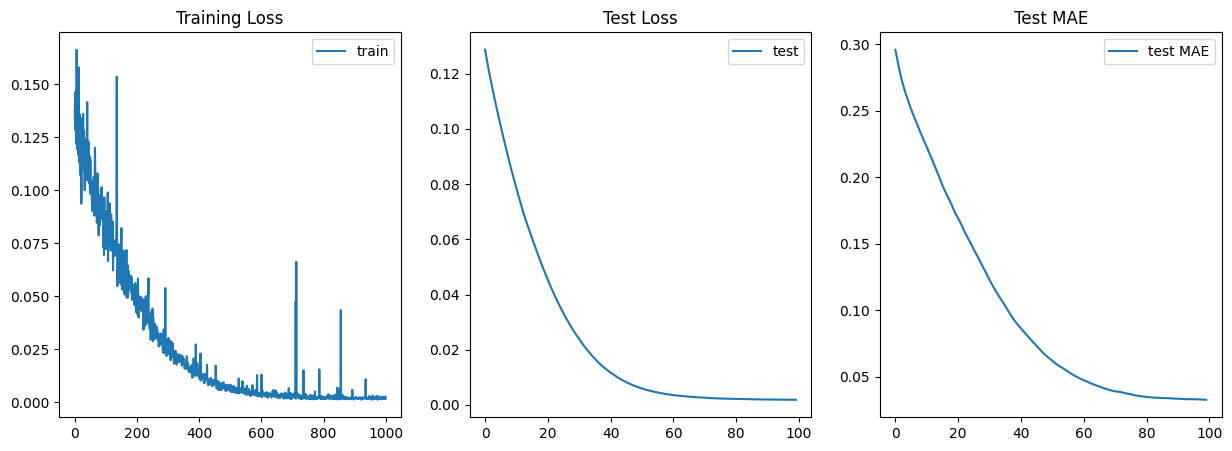

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

ax[2].plot(test_maes, label="test MAE")
ax[2].set_title('Test MAE')
ax[2].legend()

plt.show()

train a little more

In [28]:
batch_dim = 128
epochs = 1000
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-5)

Epoch 10/1000 - Loss: 0.0015216739848256111 - Test Loss: 0.0017989483894780278 - MAE: 0.032694924622774124
Epoch 20/1000 - Loss: 0.0016496538883075118 - Test Loss: 0.0017477211076766253 - MAE: 0.03226879984140396
Epoch 30/1000 - Loss: 0.0012054627295583487 - Test Loss: 0.0017104141879826784 - MAE: 0.03220915049314499
Epoch 40/1000 - Loss: 0.0027116271667182446 - Test Loss: 0.0016768861096352339 - MAE: 0.03180386871099472
Epoch 50/1000 - Loss: 0.001959532964974642 - Test Loss: 0.001642680144868791 - MAE: 0.03188735246658325
Epoch 60/1000 - Loss: 0.0020353877916932106 - Test Loss: 0.0016195845091715455 - MAE: 0.03198963776230812
Epoch 70/1000 - Loss: 0.0014947946183383465 - Test Loss: 0.001592902117408812 - MAE: 0.0316762737929821
Epoch 80/1000 - Loss: 0.0014667683281004429 - Test Loss: 0.0015744863776490092 - MAE: 0.03161611780524254
Epoch 90/1000 - Loss: 0.0016034480649977922 - Test Loss: 0.0015570779796689749 - MAE: 0.031580764800310135
Epoch 100/1000 - Loss: 0.001166792819276452 - Te

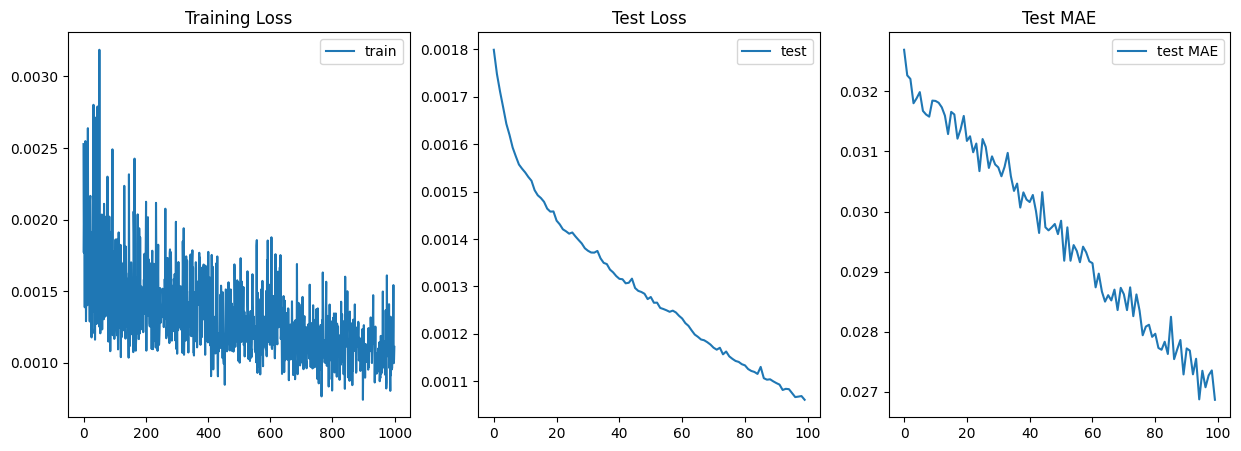

In [29]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

ax[2].plot(test_maes, label="test MAE")
ax[2].set_title('Test MAE')
ax[2].legend()

plt.show()

In [30]:
batch_dim = 128
epochs = 5000
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-6)

Epoch 10/5000 - Loss: 0.0012812550412490964 - Test Loss: 0.0010588545119389892 - MAE: 0.026940850540995598
Epoch 20/5000 - Loss: 0.0010245530866086483 - Test Loss: 0.001058506197296083 - MAE: 0.027035823091864586
Epoch 30/5000 - Loss: 0.0010355564299970865 - Test Loss: 0.0010589350713416934 - MAE: 0.027101237326860428
Epoch 40/5000 - Loss: 0.0010946639813482761 - Test Loss: 0.0010585268028080463 - MAE: 0.027101796120405197
Epoch 50/5000 - Loss: 0.000866466318257153 - Test Loss: 0.0010585059644654393 - MAE: 0.027122776955366135
Epoch 60/5000 - Loss: 0.0009801049018278718 - Test Loss: 0.0010586361167952418 - MAE: 0.027140602469444275
Epoch 70/5000 - Loss: 0.0014881473034620285 - Test Loss: 0.001058787340298295 - MAE: 0.027153505012392998
Epoch 80/5000 - Loss: 0.0010393031407147646 - Test Loss: 0.0010569560108706355 - MAE: 0.027080971747636795
Epoch 90/5000 - Loss: 0.0009247174602933228 - Test Loss: 0.001056129694916308 - MAE: 0.027048340067267418
Epoch 100/5000 - Loss: 0.0009318065131083

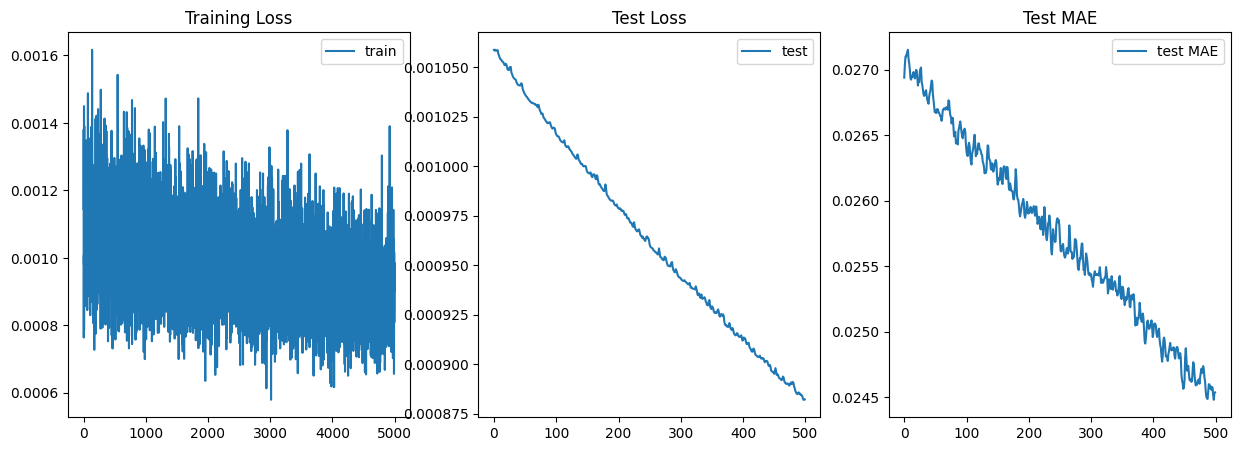

In [31]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

ax[2].plot(test_maes, label="test MAE")
ax[2].set_title('Test MAE')
ax[2].legend()

In [32]:
batch_dim = 128
epochs = 5000
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-4)

Epoch 10/5000 - Loss: 0.0011158918496221304 - Test Loss: 0.0008914688951335847 - MAE: 0.02470914088189602
Epoch 20/5000 - Loss: 0.0007229276234284043 - Test Loss: 0.0008593136444687843 - MAE: 0.02432645671069622
Epoch 30/5000 - Loss: 0.0013635677751153708 - Test Loss: 0.0008298140601255 - MAE: 0.024024851620197296
Epoch 40/5000 - Loss: 0.0007373382686637342 - Test Loss: 0.0008799563511274755 - MAE: 0.02410885877907276
Epoch 50/5000 - Loss: 0.0013146810233592987 - Test Loss: 0.0008481739205308259 - MAE: 0.02404552325606346
Epoch 60/5000 - Loss: 0.0010671007912606 - Test Loss: 0.0008283219067379832 - MAE: 0.023396164178848267
Epoch 70/5000 - Loss: 0.0009818687103688717 - Test Loss: 0.0008120054262690246 - MAE: 0.022764692083001137
Epoch 80/5000 - Loss: 0.0008065489819273353 - Test Loss: 0.0007784602930769324 - MAE: 0.022662686184048653
Epoch 90/5000 - Loss: 0.0008205455960705876 - Test Loss: 0.0007627179147675633 - MAE: 0.02312459982931614
Epoch 100/5000 - Loss: 0.0006688484572805464 - T

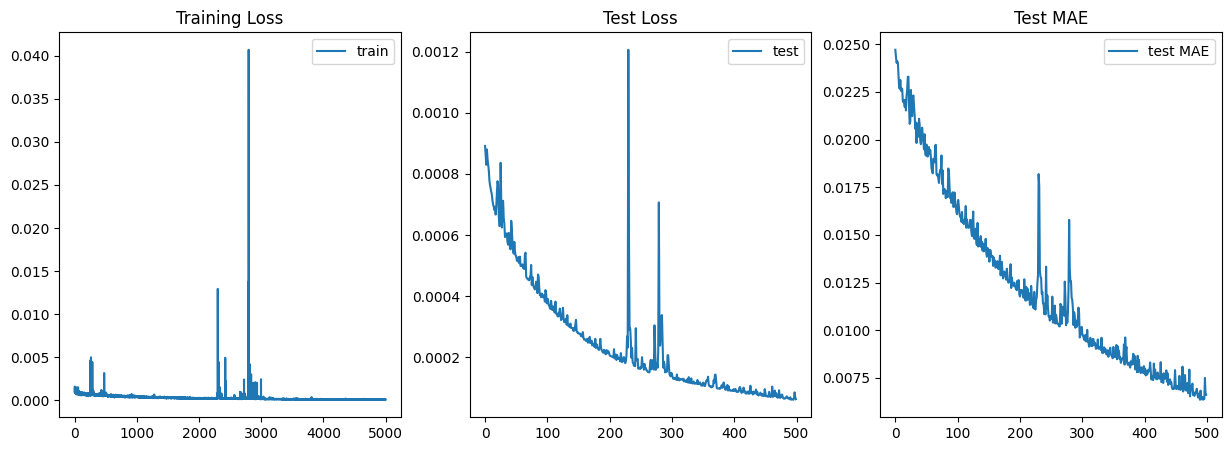

In [33]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

ax[2].plot(test_maes, label="test MAE")
ax[2].set_title('Test MAE')
ax[2].legend()

In [36]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu.onnx"
torch.onnx.export(model_gelu.to('cpu'), dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0420 14:44:42.969000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 14:44:42.975000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 14:44:42.979000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0420 14:44:42.983000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"Gemm_0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"Gemm_0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"Gemm_2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"Gemm_4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_6.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"Gemm_6.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Paramet

In [38]:
batch_dim = 128
epochs = 5000
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-4)

Epoch 10/5000 - Loss: 0.0001951183658093214 - Test Loss: 0.00021661279606632888 - MAE: 0.011168450117111206
Epoch 20/5000 - Loss: 0.0002733693108893931 - Test Loss: 0.00023762737691868097 - MAE: 0.01338424813002348
Epoch 30/5000 - Loss: 0.0001129122611018829 - Test Loss: 0.00012057824642397463 - MAE: 0.008820794522762299
Epoch 40/5000 - Loss: 0.0001026549725793302 - Test Loss: 0.00018733007891569287 - MAE: 0.009203171357512474
Epoch 50/5000 - Loss: 8.564456948079169e-05 - Test Loss: 0.00016014250286389142 - MAE: 0.008874017745256424
Epoch 60/5000 - Loss: 0.00013198144733905792 - Test Loss: 0.00011924277350772172 - MAE: 0.00900843646377325
Epoch 70/5000 - Loss: 7.958991045597941e-05 - Test Loss: 0.00010226845188299194 - MAE: 0.007766081020236015
Epoch 80/5000 - Loss: 0.0001080163856386207 - Test Loss: 9.227827831637114e-05 - MAE: 0.007858426310122013
Epoch 90/5000 - Loss: 8.986266038846225e-05 - Test Loss: 9.428693738300353e-05 - MAE: 0.00792503822594881
Epoch 100/5000 - Loss: 7.9663790

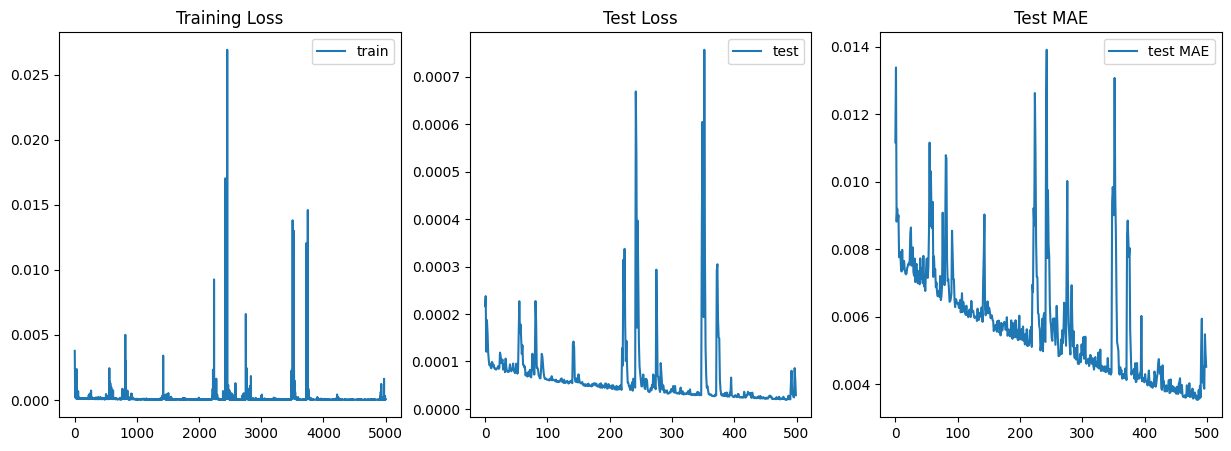

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

ax[2].plot(test_maes, label="test MAE")
ax[2].set_title('Test MAE')
ax[2].legend()

In [40]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu.onnx"
torch.onnx.export(model_gelu.to('cpu'), dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0420 15:24:37.654000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 15:24:37.658000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 15:24:37.662000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0420 15:24:37.668000 1924 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `GraphModule([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"Gemm_0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"Gemm_0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"Gemm_2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"Gemm_4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"Gemm_6.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"Gemm_6.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Paramet

# Stage-wise ReLU to GeLU Replacement

In [24]:
class ReLUGeLU(nn.Module):
  def __init__(self, theta):
    super().__init__()
    self.theta = theta

  def forward(self, x):
    return (1 - self.theta) * F.relu(x) + self.theta * F.gelu(x)

In [25]:
def replace_relu_gelu_stagewise(model_input, theta):
  # work on a copy of the input model to avoid overwrite
  model = copy.deepcopy(model_input)

  for name, module in model.named_children():
    if isinstance(module, nn.ReLU):
      setattr(model, name, ReLUGeLU(theta))

    if len(list(module.children())) > 0:
      replace_relu_gelu_stagewise(module)

  return model

In [37]:
model_gelu = replace_relu_gelu_stagewise(model, 0.05)
model_gelu_deep = replace_relu_gelu_stagewise(model_deep, 0.05)

print("--- model_gelu ---")
mean_abs_err, max_abs_err, mse = eval_model(model_gelu, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

print()
print('--- model_gelu_deep ---')
mean_abs_err, max_abs_err, mse = eval_model(model_gelu_deep, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

--- model_gelu ---
Max Absolute Error: 0.04681706428527832
Mean Absolute Error: 0.028139034286141396
MSE: 0.0009327796287834644

--- model_gelu_deep ---
Max Absolute Error: 0.08926280587911606
Mean Absolute Error: 0.026644088327884674
MSE: 0.0012007495388388634


In [35]:
thetas = np.linspace(0, 1, 20)
mean_abs_errs = []
mean_abs_errs_deep = []
for theta in thetas:
  model_gelu = replace_relu_gelu_stagewise(model, theta)
  model_gelu_deep = replace_relu_gelu_stagewise(model_deep, theta)

  mean_abs_err, _, _ = eval_model(model_gelu, spec_loader)
  mean_abs_errs.append(mean_abs_err)

  mean_abs_err, _, _ = eval_model(model_gelu_deep, spec_loader)
  mean_abs_errs_deep.append(mean_abs_err)

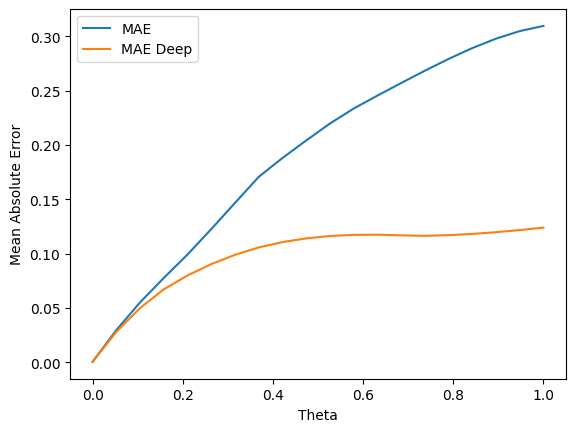

In [36]:
plt.plot(thetas, mean_abs_errs, label="MAE")
plt.plot(thetas, mean_abs_errs_deep, label="MAE Deep")
plt.xlabel("Theta")
plt.ylabel("Mean Absolute Error")
plt.legend()
plt.show()

In [46]:
theta = 0.01
model_gelu = replace_relu_gelu_stagewise(model, theta)
batch_dim = 128
epochs = 300
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-5, lossfun='mae')

Epoch 10/300 - Loss: 0.004332848824560642 - Test Loss: 1.657366919971537e-05 - MAE: 0.0033500550780445337
Epoch 20/300 - Loss: 0.00238043419085443 - Test Loss: 1.1367816114216112e-05 - MAE: 0.0023221089504659176
Epoch 30/300 - Loss: 0.0021267645061016083 - Test Loss: 6.28669431534945e-06 - MAE: 0.0018931886879727244
Epoch 40/300 - Loss: 0.0013567886780947447 - Test Loss: 3.6765040931641124e-06 - MAE: 0.0014592462684959173
Epoch 50/300 - Loss: 0.0011351493885740638 - Test Loss: 2.395537194388453e-06 - MAE: 0.0011926033766940236
Epoch 60/300 - Loss: 0.0011214500991627574 - Test Loss: 1.8377721744400333e-06 - MAE: 0.001103755785152316
Epoch 70/300 - Loss: 0.0008877554209902883 - Test Loss: 1.4645211194874719e-06 - MAE: 0.000995413982309401
Epoch 80/300 - Loss: 0.0008651932002976537 - Test Loss: 1.2290721542740357e-06 - MAE: 0.0009173848666250706
Epoch 90/300 - Loss: 0.0008009134908206761 - Test Loss: 1.0282971061315038e-06 - MAE: 0.000800232810433954
Epoch 100/300 - Loss: 0.00066261074971

In [50]:
def update_theta(model, theta_new):
  model_new = copy.deepcopy(model)
  for name, module in model_new.named_children():
    if isinstance(module, ReLUGeLU):
      module.theta = theta_new

  return model_new

In [51]:
theta += 0.01

model_gelu_new = update_theta(model_gelu, theta)

batch_dim = 128
epochs = 300
X_test = X_spec
y_test = y_spec

train_losses, test_losses, test_maes = retrain(model_gelu_new, model, X_test, y_test, epochs=epochs, batch_dim=batch_dim, rand_mode='lognormal', lr=1e-5, lossfun='mae')

Epoch 10/300 - Loss: 0.0028754237573593855 - Test Loss: 1.4215380360838026e-05 - MAE: 0.0030398196540772915
Epoch 20/300 - Loss: 0.002170186722651124 - Test Loss: 1.0359503903600853e-05 - MAE: 0.002178310416638851
Epoch 30/300 - Loss: 0.0015146922087296844 - Test Loss: 5.403760496847099e-06 - MAE: 0.0016572301974520087
Epoch 40/300 - Loss: 0.0010704158339649439 - Test Loss: 3.343955995660508e-06 - MAE: 0.0014689991949126124
Epoch 50/300 - Loss: 0.001210074289701879 - Test Loss: 2.1305688733264105e-06 - MAE: 0.00119123631156981
Epoch 60/300 - Loss: 0.0010266376193612814 - Test Loss: 1.6182674471565406e-06 - MAE: 0.0010258525144308805
Epoch 70/300 - Loss: 0.0008992941584438086 - Test Loss: 1.4863582009638776e-06 - MAE: 0.0009192348807118833
Epoch 80/300 - Loss: 0.0007304488099180162 - Test Loss: 1.117156330110447e-06 - MAE: 0.000812424928881228
Epoch 90/300 - Loss: 0.0007463910151273012 - Test Loss: 1.0747032774816034e-06 - MAE: 0.0007848141249269247
Epoch 100/300 - Loss: 0.0006364231812

## Increment Theta in a Loop

In [60]:
thetas = np.linspace(0, 1, 100)[1:]
early_stop = 0.00045
batch_dim = 128
max_epochs = 500
X_test = X_spec
y_test = y_spec

model_gelu = replace_relu_gelu_stagewise(model, thetas[0])

for theta in thetas:
  print()
  print("Set theta = ", theta)
  model_gelu_new = update_theta(model_gelu, theta)

  train_losses, test_losses, test_maes = retrain(model_gelu_new, model,
                                                 X_test, y_test, epochs=max_epochs,
                                                 batch_dim=batch_dim,
                                                 rand_mode='lognormal',
                                                 lr=1e-5, lossfun='mae',
                                                 early_stop=early_stop)


Set theta =  0.010101010101010102
Epoch 10/500 - Loss: 0.00335768167860806 - Test Loss: 1.571731991134584e-05 - MAE: 0.0033549878280609846
Epoch 20/500 - Loss: 0.002190429950132966 - Test Loss: 1.1229079063923564e-05 - MAE: 0.0023643781896680593
Epoch 30/500 - Loss: 0.0020955975633114576 - Test Loss: 7.016710242169211e-06 - MAE: 0.002019005361944437
Epoch 40/500 - Loss: 0.0012979796156287193 - Test Loss: 4.105330390302697e-06 - MAE: 0.0015293500619009137
Epoch 50/500 - Loss: 0.0013530136784538627 - Test Loss: 2.67912173512741e-06 - MAE: 0.0012110155075788498
Epoch 60/500 - Loss: 0.0011828892165794969 - Test Loss: 2.069930133075104e-06 - MAE: 0.0011739772744476795
Epoch 70/500 - Loss: 0.001112929661758244 - Test Loss: 1.6107163673950708e-06 - MAE: 0.0010340414009988308
Epoch 80/500 - Loss: 0.0007709995261393487 - Test Loss: 1.4133596550891525e-06 - MAE: 0.0009831780334934592
Epoch 90/500 - Loss: 0.0007318024872802198 - Test Loss: 1.0771444749479997e-06 - MAE: 0.0008324001100845635
Epoc

KeyboardInterrupt: 

# Just Train on the Data

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X_spec, y_spec, test_size=0.2, random_state=42)

train_ds = torch.utils.data.TensorDataset(X_train, y_train)
test_ds  = torch.utils.data.TensorDataset(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=True)

In [17]:
def train(model, train_loader, optimizer, l1_weight=0, lossfun='mse'):
  model.train()
  train_loss = 0
  correct = 0
  for batch_idx, (X, y) in enumerate(train_loader):
    optimizer.zero_grad()
    y_pred = model(X)

    if lossfun == 'mse':
      loss = F.mse_loss(y_pred, y, reduction='sum')
    elif lossfun == 'mae':
      loss = F.l1_loss(y_pred, y, reduction='sum')
    else:
      assert False, "Unknown loss function"

    if l1_weight > 0:
      l1_reg = compute_l1_norm(model)
      loss += l1_weight * l1_reg

    loss.backward()
    optimizer.step()

    train_loss += loss.item()

  train_loss = train_loss / len(train_loader.dataset)

  print(f'Train set: Average loss: {train_loss}')

  return train_loss

In [18]:
def test(model, test_loader):
  model.eval()
  test_mse_loss = 0
  test_mae_loss = 0
  correct = 0
  with torch.no_grad():
    for X, y in test_loader:
      y_pred = model(X)

      mse_loss = F.mse_loss(y_pred, y, reduction='sum')
      mae_loss = F.l1_loss(y_pred, y, reduction='sum')
      test_mse_loss += mse_loss.item()
      test_mae_loss += mae_loss.item()

    test_mseloss = test_mse_loss / len(test_loader.dataset)
    test_mae_loss = test_mae_loss / len(test_loader.dataset)

    print(f'Test set: MAE: {test_mae_loss}, MSE: {test_mse_loss}')

    return test_mse_loss,  test_mae_loss

In [19]:
def train_model(model, l1_weight=0, epochs=20, lossfun='mse'):
  optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

  best_loss = float('inf')
  best_model = None
  train_losses = []
  test_losses  = []
  for epoch in range(1, epochs+1):
    print(f'Epoch {epoch}')
    train_loss = train(model, train_loader, optimizer, l1_weight=l1_weight, lossfun=lossfun)
    test_mse_loss, test_mae_loss  = test(model, test_loader)

    if lossfun == 'mse':
      test_loss = test_mse_loss
    elif lossfun == 'mae':
      test_loss = test_mae_loss
    else:
      assert False, "Unknown loss function"

    if test_loss < best_loss:
      print("-- new best model")
      best_loss = test_loss
      best_model = copy.deepcopy(model.state_dict())

    l1_sum = compute_l1_norm(model)
    print("L1: ", l1_sum.item())

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    print()


  model.load_state_dict(best_model)
  l1_sum = compute_l1_norm(model)
  print("L1: ", l1_sum.item())

  return model, best_model, train_losses, test_losses

In [71]:
model

GraphModule(
  (Gemm_0): Linear(in_features=1, out_features=128, bias=True)
  (Relu_1): ReLU()
  (Gemm_2): Linear(in_features=128, out_features=128, bias=True)
  (Relu_3): ReLU()
  (Gemm_4): Linear(in_features=128, out_features=128, bias=True)
  (Relu_5): ReLU()
  (Gemm_6): Linear(in_features=128, out_features=1, bias=True)
)

In [20]:
model_gelu = nn.Sequential(
    nn.Linear(1, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 1)
)

## lindex Network

### Standard Training

In [21]:
model_gelu, best_model_gelu, train_losses, test_losses = train_model(model_gelu, epochs=50, lossfun='mse')

Epoch 1
Train set: Average loss: 0.009564674641592483
Test set: MAE: 0.02715389464076223, MSE: 37.05793236801401
-- new best model
L1:  2362.2060546875

Epoch 2
Train set: Average loss: 0.0004843248062531458
Test set: MAE: 0.008082617263084856, MSE: 3.798313976963982
-- new best model
L1:  2502.970703125

Epoch 3
Train set: Average loss: 0.00023052456798090376
Test set: MAE: 0.03348614831371554, MSE: 65.62601345824078
L1:  2592.086669921875

Epoch 4
Train set: Average loss: 0.00018605348764246183
Test set: MAE: 0.005448008788556888, MSE: 1.1859090030193329
-- new best model
L1:  2662.357177734375

Epoch 5
Train set: Average loss: 0.00015255236347002556
Test set: MAE: 0.008781978180696225, MSE: 4.003322921693325
L1:  2732.690185546875

Epoch 6
Train set: Average loss: 0.0001177809717393496
Test set: MAE: 0.006573833468273796, MSE: 1.7272923139389604
L1:  2771.499267578125

Epoch 7
Train set: Average loss: 0.00012613635061899483
Test set: MAE: 0.0009788370568241025, MSE: 0.05751032538864

In [22]:
print("--- model_gelu ---")
mean_abs_err, max_abs_err, mse = eval_model(model_gelu, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

--- model_gelu ---
Max Absolute Error: 0.0010107755661010742
Mean Absolute Error: 0.0002758728514891118
MSE: 1.194064935816641e-07


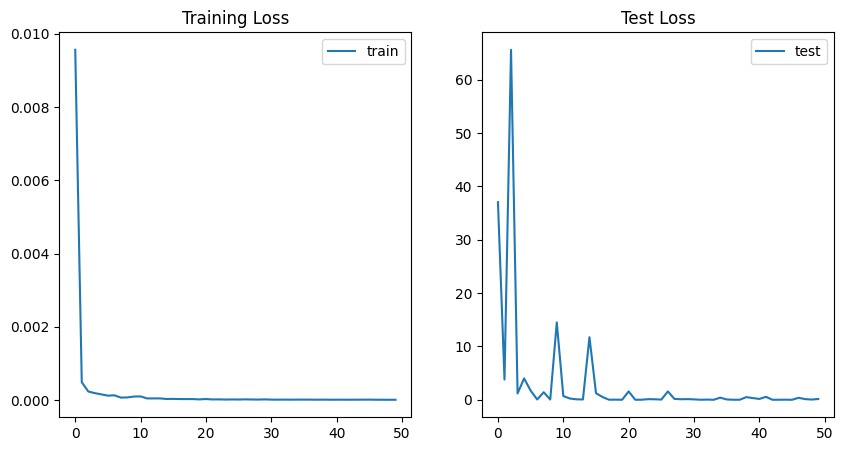

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

In [26]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu.onnx"
torch.onnx.export(model_gelu, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0421 08:30:15.501000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:30:15.503000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:30:15.505000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0421 08:30:15.507000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"6.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"6.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([0.1137], requires_g

### 5e-7 L1 Penalty

In [31]:
model_gelu.load_state_dict(best_model_gelu)
model_gelu_2e5, best_model_gelu_2e5, train_losses, test_losses = train_model(model_gelu, l1_weight=5e-7, lossfun='mse')

print("--- model_gelu_2e5 ---")
mean_abs_err, max_abs_err, mse = eval_model(model_gelu_2e5, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

Epoch 1
Train set: Average loss: 4.578179111360355e-05
Test set: MAE: 0.0016515325457499973, MSE: 0.1856811222532997
-- new best model
L1:  1923.9932861328125

Epoch 2
Train set: Average loss: 3.440987036558165e-05
Test set: MAE: 0.0014930509159598372, MSE: 0.1089984295922477
-- new best model
L1:  1657.5035400390625

Epoch 3
Train set: Average loss: 3.143484546313122e-05
Test set: MAE: 0.0005152108382176737, MSE: 0.01688939271457457
-- new best model
L1:  1525.6812744140625

Epoch 4
Train set: Average loss: 2.7345552696805423e-05
Test set: MAE: 0.0024501897295101964, MSE: 0.23491797315728036
L1:  1402.5323486328125

Epoch 5
Train set: Average loss: 2.828919818053425e-05
Test set: MAE: 0.0009255891079404231, MSE: 0.04185752699549994
L1:  1376.6466064453125

Epoch 6
Train set: Average loss: 2.7874364807575025e-05
Test set: MAE: 0.000804462587878365, MSE: 0.02975258670267067
L1:  1343.713623046875

Epoch 7
Train set: Average loss: 2.3686685054167524e-05
Test set: MAE: 0.00062476865414144

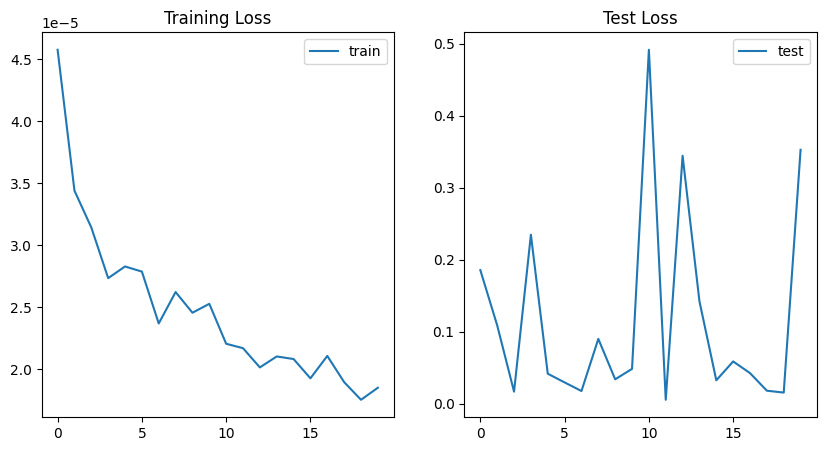

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

In [33]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu_5e-7l1.onnx"
torch.onnx.export(model_gelu_2e5, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0421 08:40:10.854000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:40:10.856000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:40:10.857000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0421 08:40:10.859000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"6.weight"<FLOAT,[1,128]>{TorchTensor(...)},
                %"6.bias"<FLOAT,[1]>{TorchTensor<FLOAT,[1]>(Parameter containing: tensor([0.1429], requires_g

## lindex_deep Network

### Standard Training

In [34]:
model_deep

GraphModule(
  (Gemm_0): Linear(in_features=1, out_features=128, bias=True)
  (Relu_1): ReLU()
  (Gemm_2): Linear(in_features=128, out_features=128, bias=True)
  (Relu_3): ReLU()
  (Gemm_4): Linear(in_features=128, out_features=128, bias=True)
  (Relu_5): ReLU()
  (Gemm_6): Linear(in_features=128, out_features=128, bias=True)
  (Relu_7): ReLU()
  (Gemm_8): Linear(in_features=128, out_features=128, bias=True)
  (Relu_9): ReLU()
  (Gemm_10): Linear(in_features=128, out_features=1, bias=True)
)

In [35]:
model_gelu_deep = nn.Sequential(
    nn.Linear(1, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 128),
    nn.GELU(),
    nn.Linear(128, 1)
)

In [36]:
model_gelu_deep, best_model_gelu_deep, train_losses, test_losses = train_model(model_gelu_deep, epochs=50, lossfun='mse')

Epoch 1
Train set: Average loss: 0.008644109908313895
Test set: MAE: 0.006653540290121374, MSE: 2.5155746487434953
-- new best model
L1:  3933.068115234375

Epoch 2
Train set: Average loss: 0.0007923220650021891
Test set: MAE: 0.00525132559265556, MSE: 1.724324203969445
-- new best model
L1:  4291.62158203125

Epoch 3
Train set: Average loss: 0.0003363591579281982
Test set: MAE: 0.009235445640981197, MSE: 4.272249297238886
L1:  4461.71435546875

Epoch 4
Train set: Average loss: 0.00022949574724827435
Test set: MAE: 0.007054639174506582, MSE: 2.4046239457675256
L1:  4606.1904296875

Epoch 5
Train set: Average loss: 0.0001759747185487963
Test set: MAE: 0.010487731214227348, MSE: 6.313362693879753
L1:  4755.79248046875

Epoch 6
Train set: Average loss: 0.0001218525415462802
Test set: MAE: 0.002734500063262109, MSE: 0.4465807406959357
-- new best model
L1:  4883.10888671875

Epoch 7
Train set: Average loss: 0.00011660781119865358
Test set: MAE: 0.0011613856303537714, MSE: 0.063580791036656

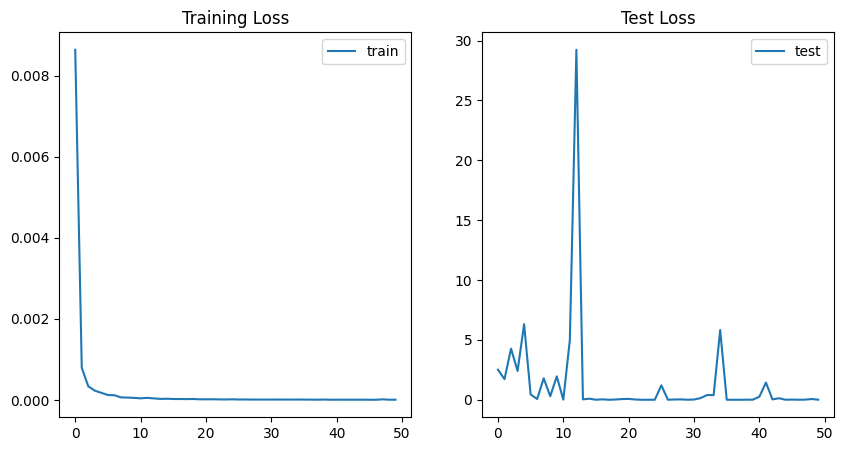

In [37]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

In [38]:
print("--- model_gelu_deep ---")
mean_abs_err, max_abs_err, mse = eval_model(model_gelu_deep, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

--- model_gelu_deep ---
Max Absolute Error: 0.001435995101928711
Mean Absolute Error: 0.00019276667444501072
MSE: 6.204620461858212e-08


In [39]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu_deep.onnx"
torch.onnx.export(model_gelu_deep, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0421 08:52:25.158000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:52:25.162000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:52:25.164000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0421 08:52:25.166000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"6.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"6.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"8.weight"<FLOAT,[128,128]>{Torc

### 5e-7 L1 Penalty

In [40]:
model_gelu_deep.load_state_dict(best_model_gelu_deep)
model_gelu_deep_2e5, best_model_gelu_deep_2e5, train_losses, test_losses = train_model(model_gelu_deep, l1_weight=5e-7, lossfun='mse')

print()
print("--- model_gelu_deep_2e5 ---")
mean_abs_err, max_abs_err, mse = eval_model(model_gelu_2e5, spec_loader)
print(f'Max Absolute Error: {max_abs_err}')
print(f'Mean Absolute Error: {mean_abs_err}')
print(f'MSE: {mse}')

Epoch 1
Train set: Average loss: 6.190952128784451e-05
Test set: MAE: 0.004125429164425566, MSE: 0.8474544062046334
-- new best model
L1:  2309.510986328125

Epoch 2
Train set: Average loss: 4.131522094433121e-05
Test set: MAE: 0.0035549986326488957, MSE: 0.5444884425960481
-- new best model
L1:  1923.5496826171875

Epoch 3
Train set: Average loss: 3.646690449935656e-05
Test set: MAE: 0.0014195309536981172, MSE: 0.0670364273883024
-- new best model
L1:  1719.4307861328125

Epoch 4
Train set: Average loss: 3.575681480298189e-05
Test set: MAE: 0.0014697569333787623, MSE: 0.08423014424806752
L1:  1615.0579833984375

Epoch 5
Train set: Average loss: 3.1987009524298326e-05
Test set: MAE: 0.00035184896215475326, MSE: 0.005269120973821373
-- new best model
L1:  1524.39697265625

Epoch 6
Train set: Average loss: 3.50612031338296e-05
Test set: MAE: 0.0005924880206906076, MSE: 0.016150270725120208
L1:  1498.9609375

Epoch 7
Train set: Average loss: 3.2331672902907914e-05
Test set: MAE: 0.0006708

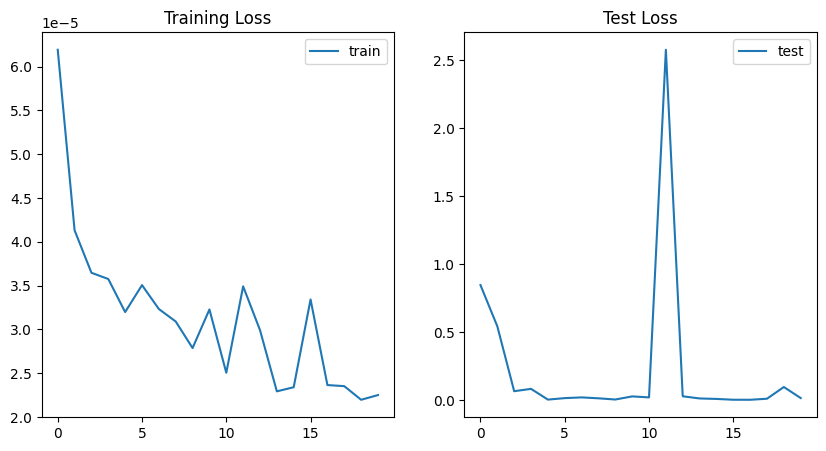

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].plot(train_losses, label="train")
ax[0].set_title('Training Loss')
ax[0].legend()

ax[1].plot(test_losses, label="test")
ax[1].set_title('Test Loss')
ax[1].legend()

In [42]:
dummy_input = torch.randn(1, 1)
filename = "lindex_gelu_deep_5e-7l1.onnx"
torch.onnx.export(model_gelu_deep_2e5, dummy_input, filename, export_params=True, do_constant_folding=True, input_names=['input'], output_names=['output'],
                  opset_version=20, external_data=False)

W0421 08:58:04.437000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:58:04.439000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0421 08:58:04.442000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0421 08:58:04.443000 4134 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.


[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 20},
            producer_name='pytorch',
            producer_version='2.10.0+cpu',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[1,1]>
            ),
            outputs=(
                %"output"<FLOAT,[1,1]>
            ),
            initializers=(
                %"0.weight"<FLOAT,[128,1]>{TorchTensor(...)},
                %"0.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"2.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"2.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"4.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"4.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"6.weight"<FLOAT,[128,128]>{TorchTensor(...)},
                %"6.bias"<FLOAT,[128]>{TorchTensor(...)},
                %"8.weight"<FLOAT,[128,128]>{Torc